# Business Understanding

## Project Domain

Domain: Retail & E-Commerce
Sub-Domain: Price Prediction & Recommender Systems

Sistem prediksi harga pakaian (Clothes Price Prediction System) yang memanfaatkan data science dan machine learning untuk membantu pelaku bisnis menentukan harga optimal berdasarkan atribut produk seperti jenis, bahan, brand, dan lain-lain.

## Problem Statements

Masalah yang Dihadapi:
1. Ketidaktepatan Penetapan Harga Produk
  * Banyak pelaku usaha fashion menetapkan harga pakaian berdasarkan asumsi atau tren subjektif tanpa analisis data historis.
  * Hal ini dapat menyebabkan harga terlalu tinggi (tidak laku) atau terlalu rendah (mengurangi margin keuntungan).

2. Kurangnya Akses ke Analisis Data
  * UMKM dan penjual online kecil sering tidak memiliki akses ke alat analisis canggih atau tim data analyst.
  * Mereka kesulitan dalam menentukan strategi harga yang kompetitif berdasarkan fitur produk seperti jenis pakaian, bahan, atau merek.

3. Persaingan Pasar yang Ketat
  * E-commerce fashion sangat kompetitif, dan tanpa strategi harga berbasis data, pelaku usaha berisiko tertinggal dari pesaing yang lebih adaptif.

4. Variabilitas Preferensi Konsumen
  * Harga yang cocok untuk satu jenis produk atau target pasar belum tentu cocok untuk lainnya.
  * Tanpa pemodelan yang tepat, penjual sulit memahami faktor-faktor apa yang memengaruhi harga pasar.

## Goals

Membangun sistem berbasis AI (Artificial Neural Network) yang dapat merekomendasikan tanaman terbaik berdasarkan parameter:
1. Jenis Pakaian (category/type)
2. Bahan atau Material
3. Merek (brand)
4. Ukuran (size)
5. Warna (color)
6. Fitur atau Deskripsi Tambahan (jika tersedia)

## Solution Statements

* Machine Learning Model
Menggunakan Artificial Neural Network (ANN) untuk memprediksi harga pakaian berdasarkan parameter seperti jenis pakaian, bahan, merek, dan atribut lainnya. Model dilatih untuk mencapai akurasi tinggi (>90%) dalam memprediksi harga yang realistis dan kompetitif.

* Aplikasi Web (Streamlit)
Membangun antarmuka pengguna berbasis web menggunakan Streamlit, sehingga pelaku usaha fashion atau pengguna umum dapat dengan mudah memasukkan detail pakaian dan langsung memperoleh estimasi harga secara instan.

* Optimasi dengan TensorFlow Lite
Model dikonversi ke format TensorFlow Lite agar ringan dan dapat dijalankan pada perangkat dengan sumber daya terbatas seperti smartphone, memungkinkan integrasi dengan aplikasi mobile e-commerce atau katalog digital.

# Data Understanding

## Import data dari kaggle

In [231]:
from google.colab import files
files.upload()

{}

In [232]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [233]:
!kaggle datasets download -d cpluzshrijayan/milkquality

Dataset URL: https://www.kaggle.com/datasets/cpluzshrijayan/milkquality
License(s): unknown
milkquality.zip: Skipping, found more recently modified local copy (use --force to force download)


In [234]:
!mkdir milkquality
!unzip milkquality.zip -d milkquality
!ls milkquality

mkdir: cannot create directory ‘milkquality’: File exists
Archive:  milkquality.zip
replace milkquality/milknew.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: milkquality/milknew.csv  
milknew.csv


## Import Library yang dibutuhkan

In [244]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam

## Exploratory Data Analysis

In [236]:
df = pd.read_csv('/content/milkquality.zip')

In [237]:
df.head()

,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,6.6,35,1,0,1,0,254,high
1,6.6,36,0,1,0,1,253,high
2,8.5,70,1,1,1,1,246,low
3,9.5,34,1,1,0,1,255,low
4,6.6,37,0,0,0,0,255,medium


<ipython-input-238-a5ae4186d893>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x='Temprature', y='Grade', inner='box', palette='Dark2')


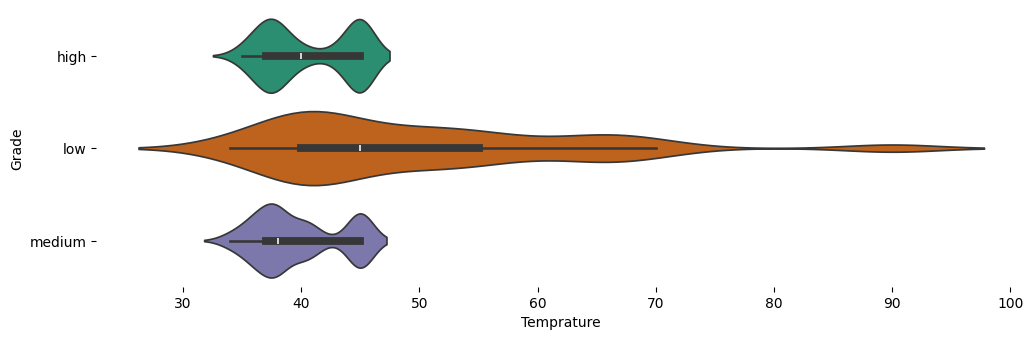

In [238]:
# @title Grade vs Temprature

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df['Grade'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='Temprature', y='Grade', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

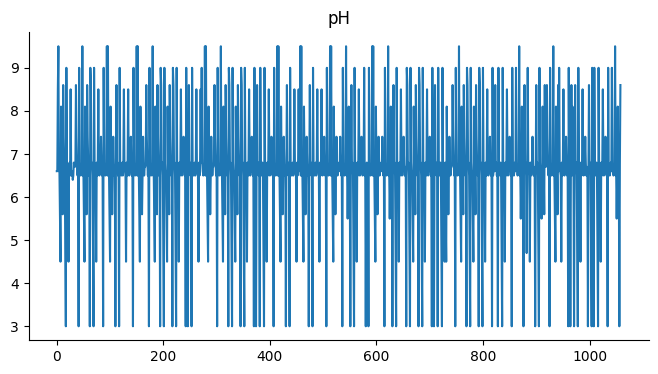

In [239]:
# @title pH

from matplotlib import pyplot as plt
df['pH'].plot(kind='line', figsize=(8, 4), title='pH')
plt.gca().spines[['top', 'right']].set_visible(False)

<ipython-input-240-1de3814194db>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x='Odor', y='Grade', inner='box', palette='Dark2')


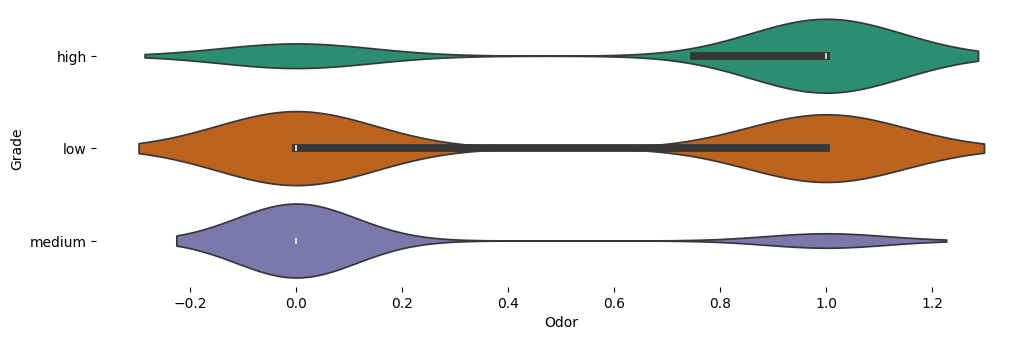

In [240]:
# @title Grade vs Odor

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df['Grade'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='Odor', y='Grade', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

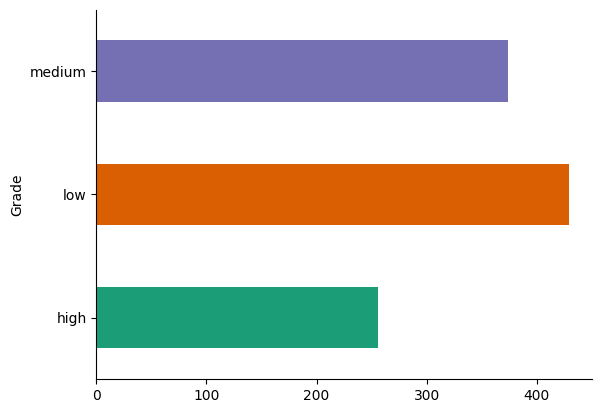

In [241]:
# @title Grade

from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('Grade').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

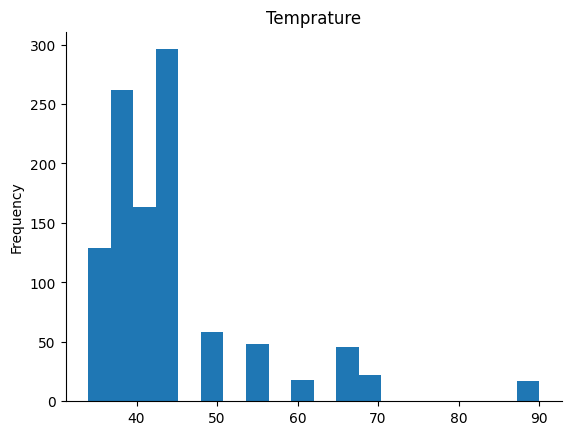

In [242]:
# @title Temprature

from matplotlib import pyplot as plt
df['Temprature'].plot(kind='hist', bins=20, title='Temprature')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [243]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pH          1059 non-null   float64
 1   Temprature  1059 non-null   int64  
 2   Taste       1059 non-null   int64  
 3   Odor        1059 non-null   int64  
 4   Fat         1059 non-null   int64  
 5   Turbidity   1059 non-null   int64  
 6   Colour      1059 non-null   int64  
 7   Grade       1059 non-null   object 
dtypes: float64(1), int64(6), object(1)
memory usage: 66.3+ KB


# Data Preparation

In [207]:
# pisahkan fitur dan target
X = df.drop(columns=["Grade"])
y = df["Grade"]

In [208]:
# Encode label target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [209]:
# Normalisasi fitur
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [210]:
# Bagi data menjadi train dan test set
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y_encoded,
                                                    test_size=0.2,
                                                    random_state=42)

# Modeling

In [211]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(le.classes_), activation="softmax")
])

In [212]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [213]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,459 (44.76 KB)

 Trainable params: 11,459 (44.76 KB)

 Non-trainable params: 0 (0.00 B)

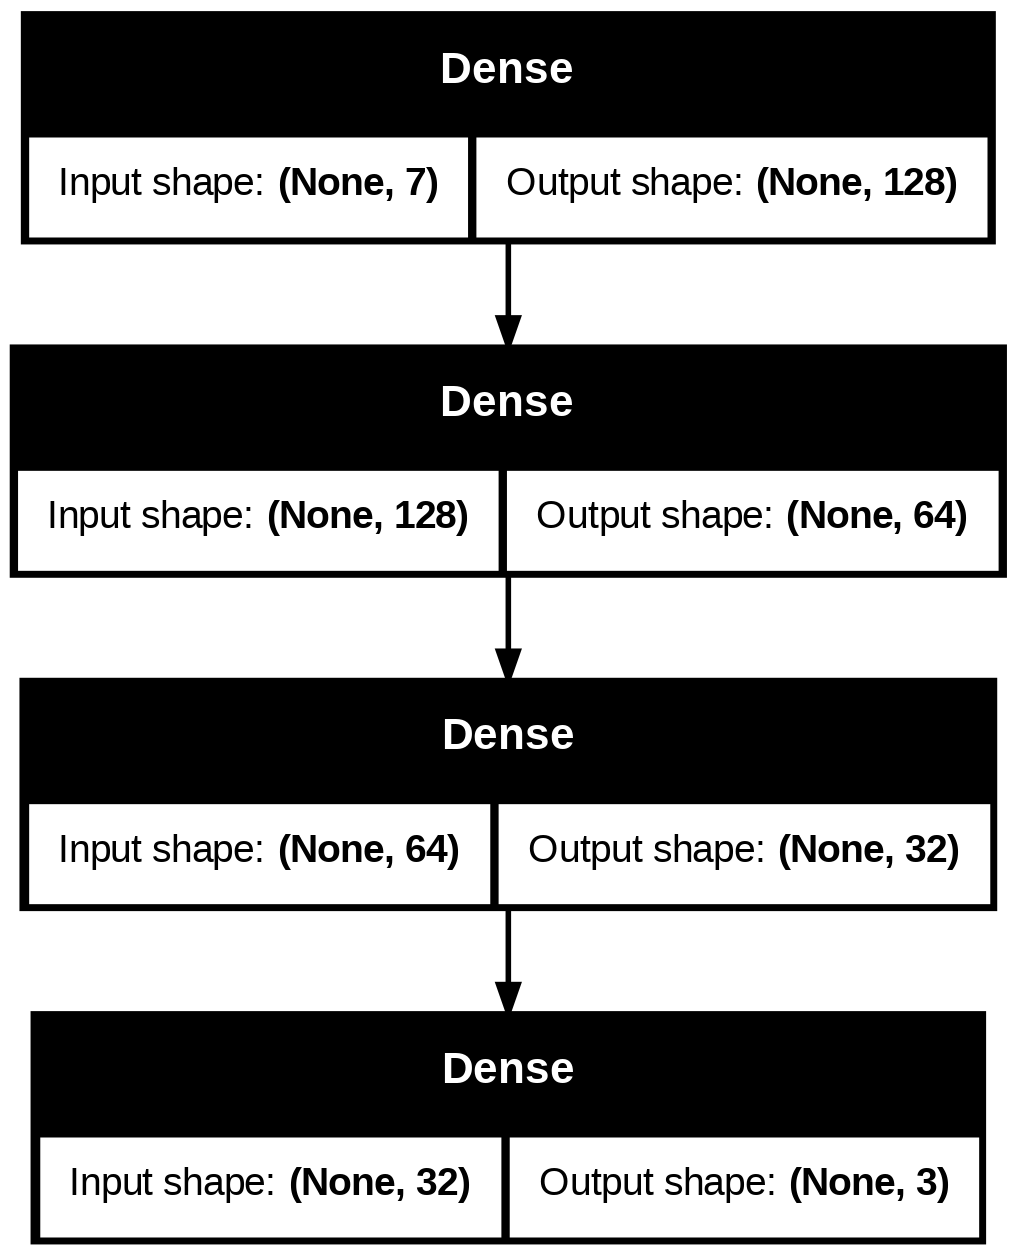

In [214]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [215]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_data=(X_test, y_test))

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5541 - loss: 1.0082 - val_accuracy: 0.6557 - val_loss: 0.7969
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6922 - loss: 0.7322 - val_accuracy: 0.6934 - val_loss: 0.5767
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7891 - loss: 0.5166 - val_accuracy: 0.8066 - val_loss: 0.4478
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8801 - loss: 0.3894 - val_accuracy: 0.8726 - val_loss: 0.3424
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8802 - loss: 0.3223 - val_accuracy: 0.8821 - val_loss: 0.3127
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9110 - loss: 0.2635 - val_accuracy: 0.8962 - val_loss: 0.2454
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9291 - loss: 0.2171 - val_accuracy: 0.9198 - val_loss: 0.2283
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9278 - loss: 0.1967 - val_accuracy: 0.9340 - val_loss:

# Evaluation

In [216]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9363 - loss: 0.1230 
Akurasi Model: 0.9434
Loss Model: 0.1023


In [225]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

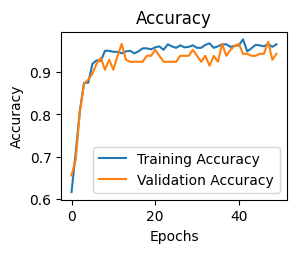

In [226]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

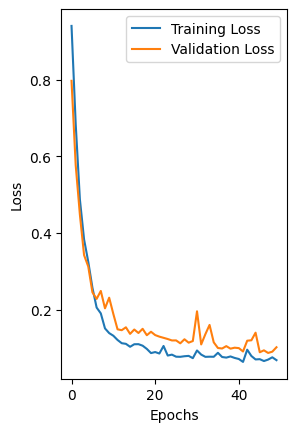

In [227]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


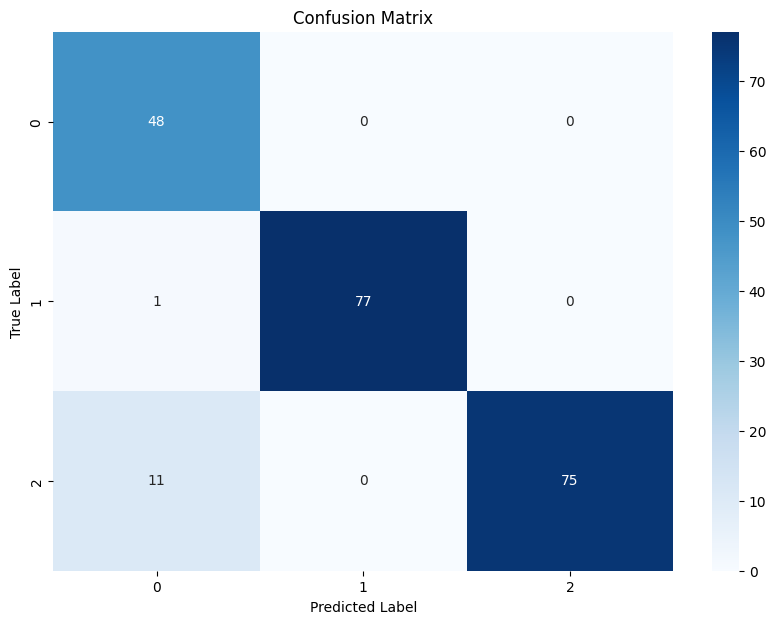

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        48
           1       1.00      0.99      0.99        78
           2       1.00      0.87      0.93        86

    accuracy                           0.94       212
   macro avg       0.93      0.95      0.94       212
weighted avg       0.95      0.94      0.94       212



In [245]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [246]:
sample_input = np.array([[78, 42 ,42, 20.13, 81.60,	7.62, 262.71]])
sample_input_df = pd.DataFrame(sample_input)


In [247]:
sample_input_scaled = scaler.transform(sample_input_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [248]:
predicted_class = np.argmax(model.predict(sample_input_scaled))
predicted_crop = le.inverse_transform([predicted_class])

print(f"Tanaman yang direkomendasikan: {predicted_crop[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Tanaman yang direkomendasikan: high


## Save Model

In [249]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('crop_recommendation.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp1acjfwhp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7), dtype=tf.float32, name='keras_tensor_32')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134987540892560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987540895824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987540904656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987540904080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987540903696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987403697360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987403696208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134987403694096: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [250]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']